# 29 · GSE135779 · scRNA_seq · heatmap, k-means on both axes

Same matrix and traits as notebook 28. k-means (50 random starts) on genes and on children separately;
for each axis k is the value from 2 to 8 with the highest mean silhouette width.

**Tests.**
1. Gene clusters against GSE65391 modules: cross-table and adjusted Rand index (ARI).
2. Children's clusters against each trait: Kruskal–Wallis or Fisher, BH q. **A finding** is q < 0.05.
3. Children's k-means clusters against the hierarchical groups of notebook 28: ARI.

In [1]:
source("../src/paths.R")
suppressMessages({library(ComplexHeatmap); library(circlize); library(cluster)})
x    <- readRDS(art("GSE135779", "expression.rds"))
meta <- readRDS(art("GSE135779", "metadata.rds"))
mg   <- read.csv(art("GSE65391", "module_genes.csv"))
sle  <- rownames(meta)[meta$sle == 1]; m <- meta[sle, ]
hub  <- do.call(rbind, lapply(split(mg, mg$module), function(d) head(d[order(-d$kME), ], 10)))
hub  <- hub[hub$gene %in% rownames(x$E), ]
Z <- t(scale(t(x$E[hub$gene, sle])))
Z <- Z[rowSums(is.na(Z)) == 0, ]; gene_module <- hub$module[match(rownames(Z), hub$gene)]
traits <- data.frame(sledai = m$SLEDAI, stage = as.numeric(cut(m$SLEDAI, c(-Inf, 0, 5, 10, 19, Inf))) - 1,
  nephritis_any = m$Neph_all, nephritis_proliferative = ifelse(is.na(m$Neph_class), NA, as.numeric(grepl("3|4", m$Neph_class))),
  age = m$age, female = as.numeric(m$Gender == "F"), c3 = m$C3, c4 = m$C4, wbc = m$WBC,
  neutrophil_count = m$NEU_ABS, lymphocyte_count = m$LYM_ABS, platelet_count = m$PLATELETS,
  oral_steroids = m$OS, mycophenolate = m$MMF, hydroxychloroquine = m$Plaquenil, methotrexate = m$MTX, mdg = m$MDG)
ari <- function(a, b) {
  tab <- table(a, b); c2 <- function(x) x * (x - 1) / 2
  e <- sum(c2(rowSums(tab))) * sum(c2(colSums(tab))) / c2(sum(tab))
  (sum(c2(tab)) - e) / ((sum(c2(rowSums(tab))) + sum(c2(colSums(tab)))) / 2 - e)
}
choose_k <- function(X, label) {
  set.seed(SEED)
  fits <- lapply(2:8, function(k) kmeans(X, k, nstart = 50, iter.max = 100))
  sil  <- sapply(fits, function(f) mean(silhouette(f$cluster, dist(X))[, "sil_width"]))
  print(data.frame(axis = label, k = 2:8, mean_silhouette = round(sil, 3)))
  fits[[which.max(sil)]]
}
gene_cluster  <- factor(paste0("G", choose_k(Z, "genes")$cluster))
child_cluster <- factor(paste0("K", choose_k(t(Z), "children")$cluster))
c(k_genes = nlevels(gene_cluster), k_children = nlevels(child_cluster)); table(child_cluster)

   axis k mean_silhouette
1 genes 2           0.176
2 genes 3           0.208
3 genes 4           0.213
4 genes 5           0.230
5 genes 6           0.234
6 genes 7           0.239
7 genes 8           0.260


      axis k mean_silhouette
1 children 2           0.134
2 children 3           0.138
3 children 4           0.137
4 children 5           0.146
5 children 6           0.129
6 children 7           0.132
7 children 8           0.137


k_genes k_children 
         8          5

child_cluster
K1 K2 K3 K4 K5 
 3 10  7  1 12 

**Result.** Children: k = 5 (silhouette 0.146; the range is flat, 0.129 to 0.146), clusters of 3,
10, 7, 1 and 12. Genes: k = 8, the edge of the range.

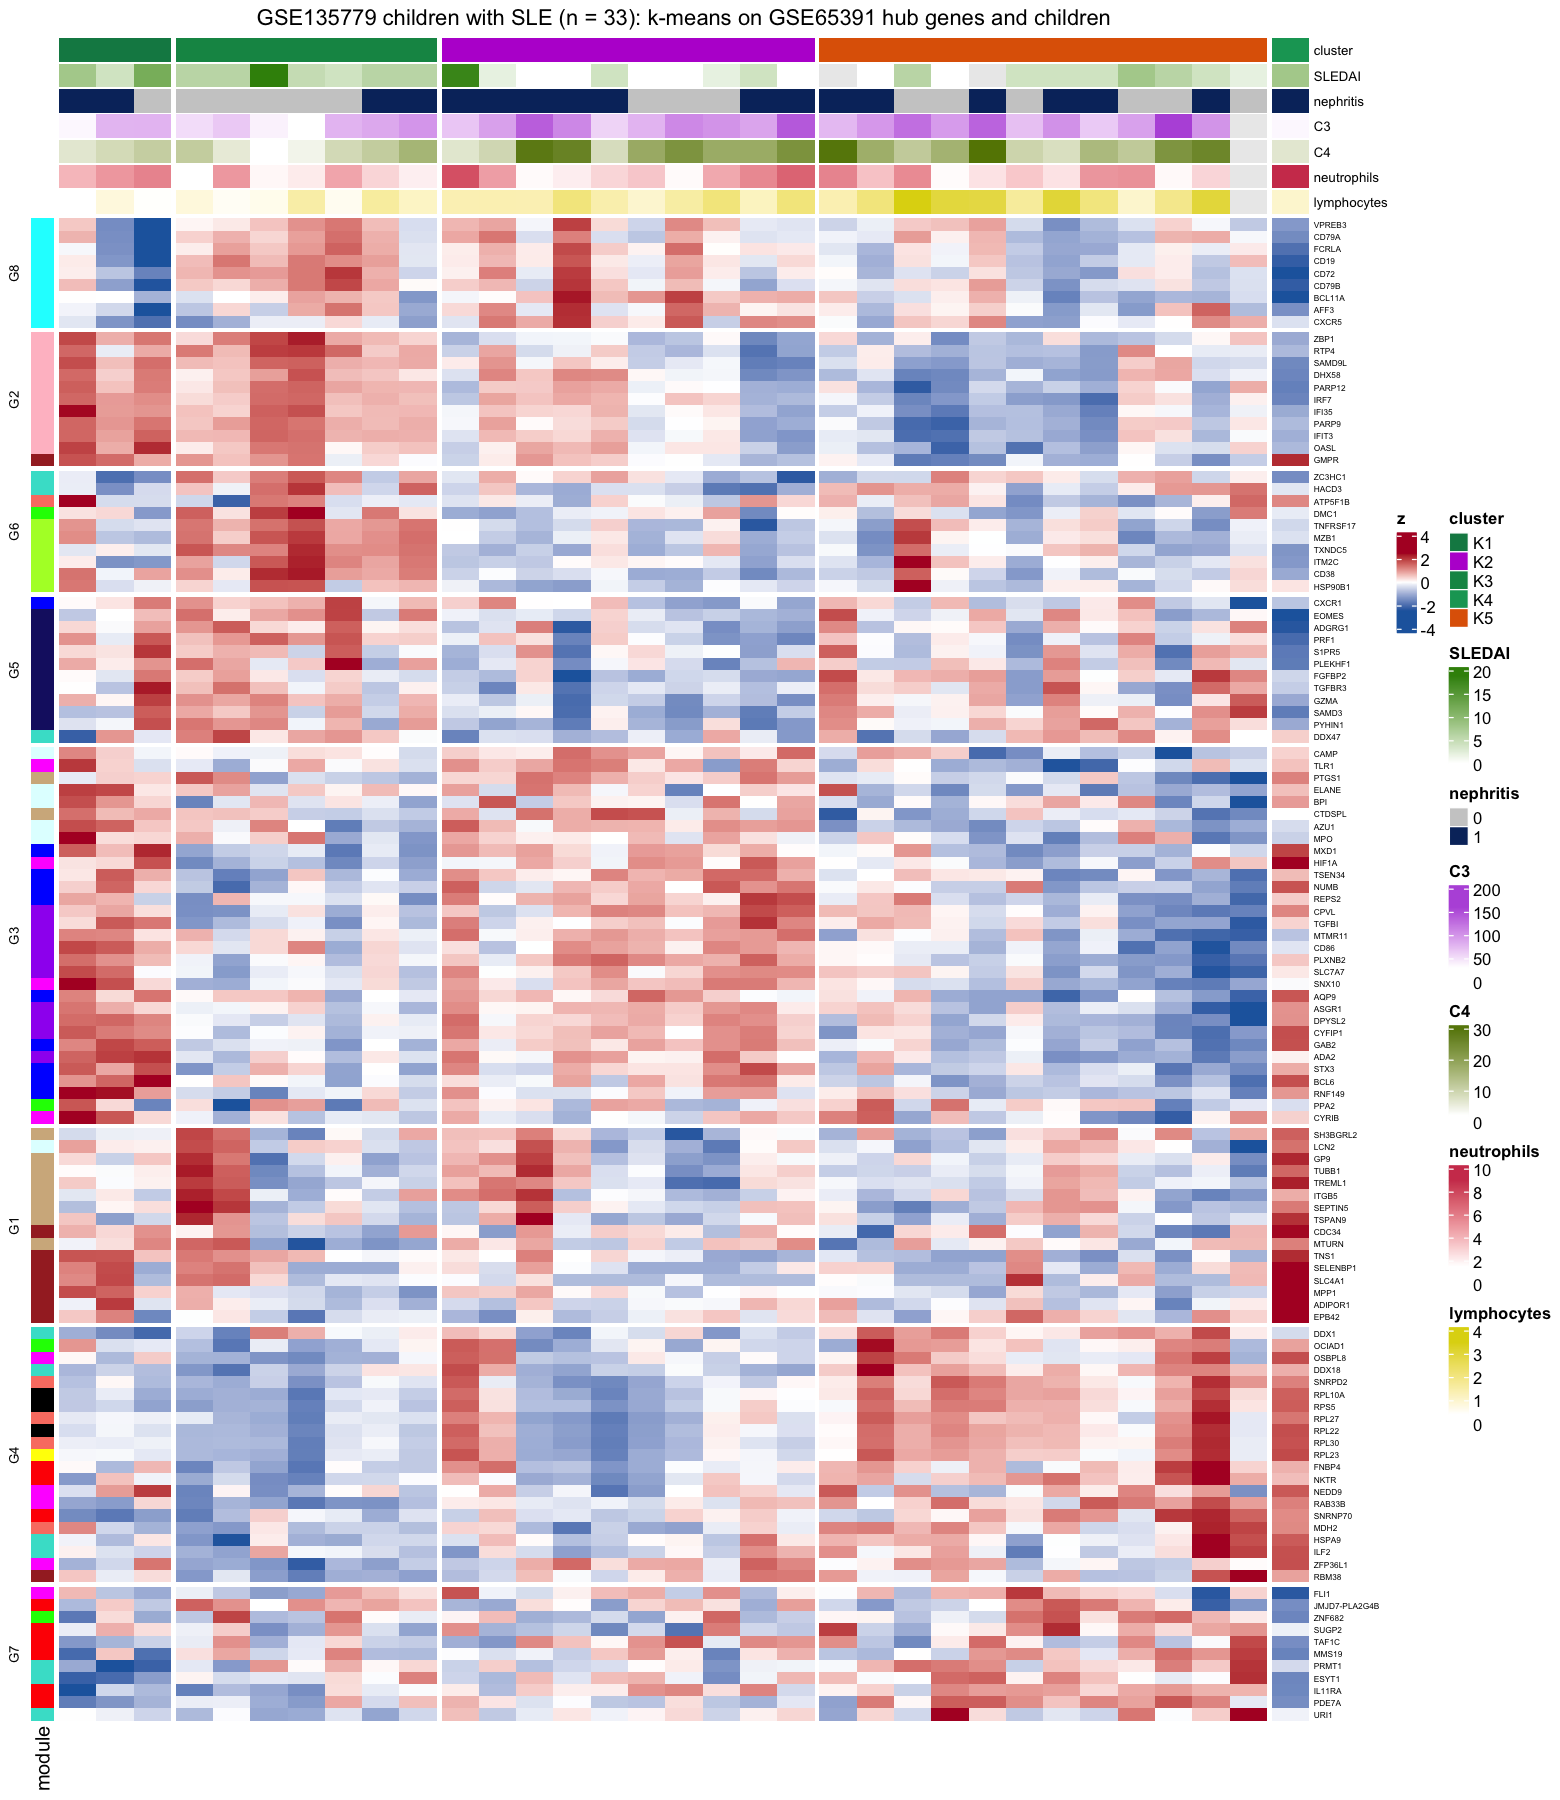

In [2]:
options(repr.plot.width = 13, repr.plot.height = 15)
Heatmap(pmin(pmax(Z, -2.5), 2.5), name = "z", col = colorRamp2(c(-2.5, 0, 2.5), c("#2166AC", "white", "#B2182B")),
        row_split = gene_cluster, column_split = child_cluster,
        clustering_method_rows = "ward.D2", clustering_method_columns = "ward.D2",
        show_row_dend = FALSE, show_column_dend = FALSE, show_column_names = FALSE,
        row_names_gp = gpar(fontsize = 5), row_title_gp = gpar(fontsize = 8),
        left_annotation = rowAnnotation(module = gene_module, col = list(module = setNames(unique(gene_module), unique(gene_module))), show_legend = FALSE),
        top_annotation = HeatmapAnnotation(cluster = child_cluster, SLEDAI = traits$sledai, nephritis = factor(traits$nephritis_any),
                                           C3 = traits$c3, C4 = traits$c4, neutrophils = traits$neutrophil_count,
                                           lymphocytes = traits$lymphocyte_count, na_col = "grey92",
                                           col = list(nephritis = c("0" = "grey80", "1" = "#08306b")),
                                           annotation_name_gp = gpar(fontsize = 8)),
        column_title = "GSE135779 children with SLE (n = 33): k-means on GSE65391 hub genes and children")

**Test 1.** Gene clusters against GSE65391 modules.

In [3]:
table(module = gene_module, gene_cluster = gene_cluster)
c(ARI_gene_clusters_vs_array_modules = round(ari(gene_cluster, gene_module), 3))

              gene_cluster
module         G1 G2 G3 G4 G5 G6 G7 G8
  black         0  0  0  3  0  0  0  0
  blue          0  0  9  0  1  0  0  0
  brown         7  1  0  1  0  0  0  0
  cyan          0  0  0  0  0  0  0  9
  green         0  0  1  1  0  1  1  0
  greenyellow   0  0  0  0  0  6  0  0
  lightcyan     1  0  5  0  0  0  0  0
  magenta       0  0  4  4  0  0  1  0
  midnightblue  0  0  0  0 10  0  0  0
  pink          0 10  0  0  0  0  0  0
  purple        0  0 10  0  0  0  0  0
  red           0  0  0  3  0  0  6  0
  salmon        0  0  0  4  0  1  0  0
  tan           8  0  2  0  0  0  0  0
  turquoise     0  0  0  4  1  2  3  0
  yellow        0  0  0  1  0  0  0  0

ARI_gene_clusters_vs_array_modules 
                             0.382

**Result.** ARI 0.38. The hub genes of pink, purple, midnightblue and cyan still cluster together; the
lightcyan and brown hub genes do not.

**Test 2.** Children's clusters against each trait.

In [4]:
out <- do.call(rbind, lapply(names(traits), function(tr) {
  v <- traits[[tr]]; ok <- !is.na(v); binary <- all(v %in% c(0, 1, NA))
  if (length(unique(v[ok])) < 2 || length(unique(child_cluster[ok])) < 2) return(NULL)
  p <- if (binary) fisher.test(table(child_cluster[ok], v[ok]))$p.value else kruskal.test(v[ok], child_cluster[ok])$p.value
  data.frame(trait = tr, test = if (binary) "Fisher" else "Kruskal-Wallis", n = sum(ok), p = p)
}))
out$q <- p.adjust(out$p, "BH"); out[order(out$p), ]

,trait,test,n,p,q
,<chr>,<chr>,<int>,<dbl>,<dbl>
11,lymphocyte_count,Kruskal-Wallis,32,0.001353023,0.02300139
17,mdg,Kruskal-Wallis,33,0.014066007,0.05901792
5,age,Kruskal-Wallis,33,0.016202649,0.05901792
1,sledai,Kruskal-Wallis,31,0.016782770,0.05901792
8,c4,Kruskal-Wallis,32,0.017358213,0.05901792
7,c3,Kruskal-Wallis,32,0.029209253,0.08275955
2,stage,Kruskal-Wallis,31,0.038000166,0.09228612
9,wbc,Kruskal-Wallis,32,0.050594707,0.10751375
10,neutrophil_count,Kruskal-Wallis,32,0.161093579,0.30428787


**Result.** Lymphocyte count differs between the clusters (q = 0.02). No other trait reaches q < 0.05.

**Test 3.** k-means against the hierarchical groups (same k rule as notebook 28).

In [5]:
hc  <- hclust(dist(t(Z)), method = "ward.D2")
sil <- sapply(2:8, function(k) mean(silhouette(cutree(hc, k), dist(t(Z)))[, "sil_width"]))
hc_group <- factor(paste0("H", cutree(hc, (2:8)[which.max(sil)])))
table(hclust = hc_group, kmeans = child_cluster)
c(ARI_kmeans_vs_hclust = round(ari(hc_group, child_cluster), 3))

      kmeans
hclust K1 K2 K3 K4 K5
    H1  0  6  0  0  0
    H2  0  1  2  0  0
    H3  0  0  0  0  2
    H4  0  2  0  0  3
    H5  3  1  0  0  0
    H6  0  0  0  1  0
    H7  0  0  0  0  7
    H8  0  0  5  0  0

ARI_kmeans_vs_hclust 
               0.456

**Result.** ARI 0.46: the two methods give different groupings, consistent with the flat silhouette.